In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [ ]:
# Leitura da base
df = pd.read_csv('Obesity.csv')
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [19]:
# 1. Separando as features (X) e o target (y)
X = df.drop(columns=['Obesity'])  
y = df['Obesity']

# 2. Dividindo em Treino (80%) e Teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste: {X_test.shape[0]} linhas")

Treino: 1688 linhas
Teste: 423 linhas


In [ ]:
# 1. Função para arredondar ruídos decimais das variáveis discretas
def arredondar_valores(X):
    return np.round(X)

round_transformer = FunctionTransformer(arredondar_valores)

# 2. Mapeamento das colunas conforme o dicionário de dados
colunas_continuas = ['Height', 'Weight']

# Numéricas com ruído decimal, mas que representam escalas/graus ordenados
colunas_num_ordinais = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

# Categóricas ordinais com escala clara de frequência (Texto -> Número Ordenado)
colunas_cat_ordinais = ['CAEC', 'CALC']
escala_frequencia = ['no', 'Sometimes', 'Frequently', 'Always']

# Categóricas nominais puros (Sem ordem hierárquica -> One-Hot Encoding)
colunas_categoricas_nominais = ['Gender', 'family_history', 'FAVC', 'SMOKE', 'SCC', 'MTRANS']

# 3. Construção das sub-pipelines de processamento
pipeline_continua = Pipeline(steps=[
    ('scaler', StandardScaler())
])

pipeline_num_ordinal = Pipeline(steps=[
    ('round', round_transformer),
    ('scaler', StandardScaler()) 
])

pipeline_cat_ordinal = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[escala_frequencia, escala_frequencia])),
    ('scaler', StandardScaler())
])

pipeline_nominal = Pipeline(steps=[
    ('onehot_encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# 4. ColumnTransformer Principal (A central unificada de Feature Engineering)
preprocessor = ColumnTransformer(transformers=[
    ('num_cont', pipeline_continua, colunas_continuas),
    ('num_ord', pipeline_num_ordinal, colunas_num_ordinais),
    ('cat_ord', pipeline_cat_ordinal, colunas_cat_ordinais),
    ('nominal', pipeline_nominal, colunas_categoricas_nominais)
])

print("Pipeline de pré-processamento corrigida e estruturada com sucesso!")

Pipeline de pré-processamento corrigida e estruturada com sucesso!


In [ ]:
# 1. Inicializando os algoritmos base
algoritmos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Dicionário para armazenar as pipelines completas e treinadas
pipelines_treinadas = {}

for nome, modelo in algoritmos.items():
    print(f"Treinando a pipeline completa para: {nome}...")
    
    # Esteira unificada
    pipe_completa = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])
    
    # Treinando passando os dados brutos ORIGINAIS
    pipe_completa.fit(X_train, y_train)
    pipelines_treinadas[nome] = pipe_completa

print("\n--- Todos os modelos foram treinados via Pipeline com sucesso! ---")

Treinando a pipeline completa para: Logistic Regression...
Treinando a pipeline completa para: Random Forest...
Treinando a pipeline completa para: Gradient Boosting...

--- Todos os modelos foram treinados via Pipeline com sucesso! ---


In [ ]:
# Buscando os melhores parâmetros para o Random Forest através da Pipeline
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None],
    'model__min_samples_split': [2, 5]
}

print("Iniciando GridSearchCV para o Random Forest (isso pode levar alguns segundos)...")
grid_rf = GridSearchCV(pipelines_treinadas["Random Forest"], param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"\nMelhor acurácia obtida na Validação Cruzada: {grid_rf.best_score_:.4f}")
print("Melhores parâmetros encontrados para o Random Forest:", grid_rf.best_params_)

# Atualizando o dicionário de modelos com a versão otimizada do Random Forest
pipelines_treinadas["Random Forest Otimizado"] = grid_rf.best_estimator_

Iniciando GridSearchCV para o Random Forest (isso pode levar alguns segundos)...

Melhor acurácia obtida na Validação Cruzada: 0.9402
Melhores parâmetros encontrados para o Random Forest: {'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}


RELATÓRIO DE CLASSIFICAÇÃO: Logistic Regression
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.96      0.92        54
      Normal_Weight       0.78      0.69      0.73        58
     Obesity_Type_I       0.92      0.93      0.92        70
    Obesity_Type_II       0.94      1.00      0.97        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.72      0.74      0.73        58
Overweight_Level_II       0.81      0.76      0.79        58

           accuracy                           0.87       423
          macro avg       0.86      0.87      0.86       423
       weighted avg       0.87      0.87      0.87       423

RELATÓRIO DE CLASSIFICAÇÃO: Random Forest
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.94      0.96        54
      Normal_Weight       0.81      0.86      0.83        58
     Obesity_Type_I       0.94      0.97      0.96  

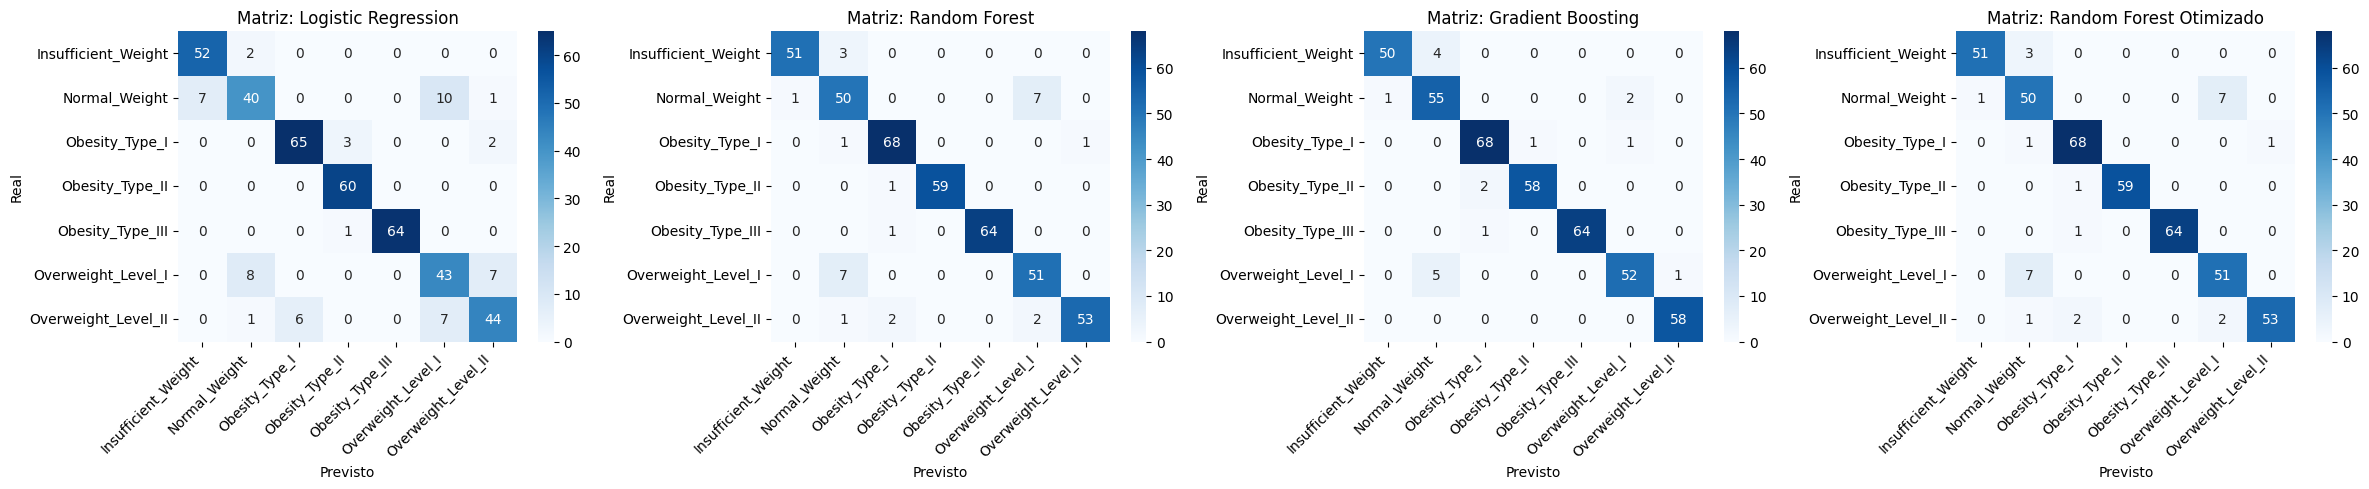

In [ ]:
# 1. Exibindo o Relatório de Classificação para cada modelo
for nome, pipe in pipelines_treinadas.items():
    pred_classes = pipe.predict(X_test)
    print("=" * 60)
    print(f"RELATÓRIO DE CLASSIFICAÇÃO: {nome}")
    print("=" * 60)
    print(classification_report(y_test, pred_classes))

# 2. Plotando as Matrizes de Confusão lado a lado
fig, axes = plt.subplots(1, len(pipelines_treinadas), figsize=(24, 5))

for i, (nome, pipe) in enumerate(pipelines_treinadas.items()):
    pred_classes = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred_classes)
    classes = sorted(y_test.unique())
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=classes, yticklabels=classes)
    axes[i].set_title(f'Matriz: {nome}')
    axes[i].set_ylabel('Real')
    axes[i].set_xlabel('Previsto')
    axes[i].set_xticklabels(classes, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [28]:
# Rastrear o melhor modelo e sua respectiva acurácia
melhor_nome = None
melhor_acuracia = 0.0
melhor_pipeline_final = None


# 2. Varre todas as pipelines treinadas para encontrar a de maior score no teste
for nome, pipe in pipelines_treinadas.items():
    acuracia_teste = pipe.score(X_test, y_test)
    print(f"Modelo: {nome:25} | Acurácia no Teste: {acuracia_teste:.4f}")
    
    if acuracia_teste > melhor_acuracia:
        melhor_acuracia = acuracia_teste
        melhor_nome = nome
        melhor_pipeline_final = pipe

print("-" * 65)
print(f"Modelo vencedor: {melhor_nome} com {melhor_acuracia*100:.2f}% de acurácia!")
print("-" * 65)

# 3. Salva isoladamente apenas a pipeline com a acurácia mais alta
arquivo_saida = 'pipeline_obesity_model.pkl'
joblib.dump(melhor_pipeline_final, arquivo_saida)

print(f"Sucesso! O arquivo '{arquivo_saida}' foi gerado contendo APENAS o modelo {melhor_nome}.")

Modelo: Logistic Regression       | Acurácia no Teste: 0.8700
Modelo: Random Forest             | Acurácia no Teste: 0.9362
Modelo: Gradient Boosting         | Acurácia no Teste: 0.9574
Modelo: Random Forest Otimizado   | Acurácia no Teste: 0.9362
-----------------------------------------------------------------
Modelo vencedor: Gradient Boosting com 95.74% de acurácia!
-----------------------------------------------------------------
Sucesso! O arquivo 'pipeline_obesity_model.pkl' foi gerado contendo APENAS o modelo Gradient Boosting.
